# Ergodicity

### Objective

The objective of this experiment is to empirically verify the **ergodicity assumption** used in Stochastic Gradient Descent (SGD).

The ergodicity assumption states that randomly sampled mini-batches should be representative of the underlying training data distribution. If this assumption holds, gradients computed from mini-batches approximate the gradient computed using the entire dataset, enabling SGD to converge towards the optimum.

### Methodology

The verification is performed in two stages:

1. Compare the average class distribution of randomly sampled mini-batches with the class distribution of the complete training dataset for different batch sizes.
2. Quantify the similarity using the **Kullback-Leibler (KL) Divergence**, where lower values indicate that the mini-batch distribution is closer to the dataset distribution.

In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
from src.utils import load_config
PROJECT_ROOT = Path.cwd().parent
config = load_config(config_path=os.path.join(PROJECT_ROOT, "configs/data.yaml"))
data_dir = config["root"]
batch_size = config["batch_size"]

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm 
from src.data import get_dataloaders

In [17]:
train_loader, _, _ = get_dataloaders(data_dir=data_dir,batch_size=1,shuffle=False)

labels = []

for _, y in train_loader:
    labels.extend(y.numpy())

counts = Counter(labels)

dataset_dist = np.array([counts.get(i, 0) for i in range(10)],dtype=float)
dataset_dist /= dataset_dist.sum()

print("Training Dataset Distribution")
print(dataset_dist)

Training Dataset Distribution
[0.09872 0.11236 0.0993  0.10218 0.09736 0.09036 0.09864 0.10442 0.09752
 0.09914]


### Step 2: Compare Mini-batch Distributions

To evaluate whether randomly sampled mini-batches are representative of the training dataset. The average class distribution is computed for different batch sizes.

For each batch size, up to 1000 randomly sampled mini-batches are drawn. The class distribution of each mini-batch is computed and the average distribution across all sampled mini-batches is compared with the full training dataset distribution.

100%|██████████████████████████████████████████| 10/10 [00:25<00:00,  2.54s/it]


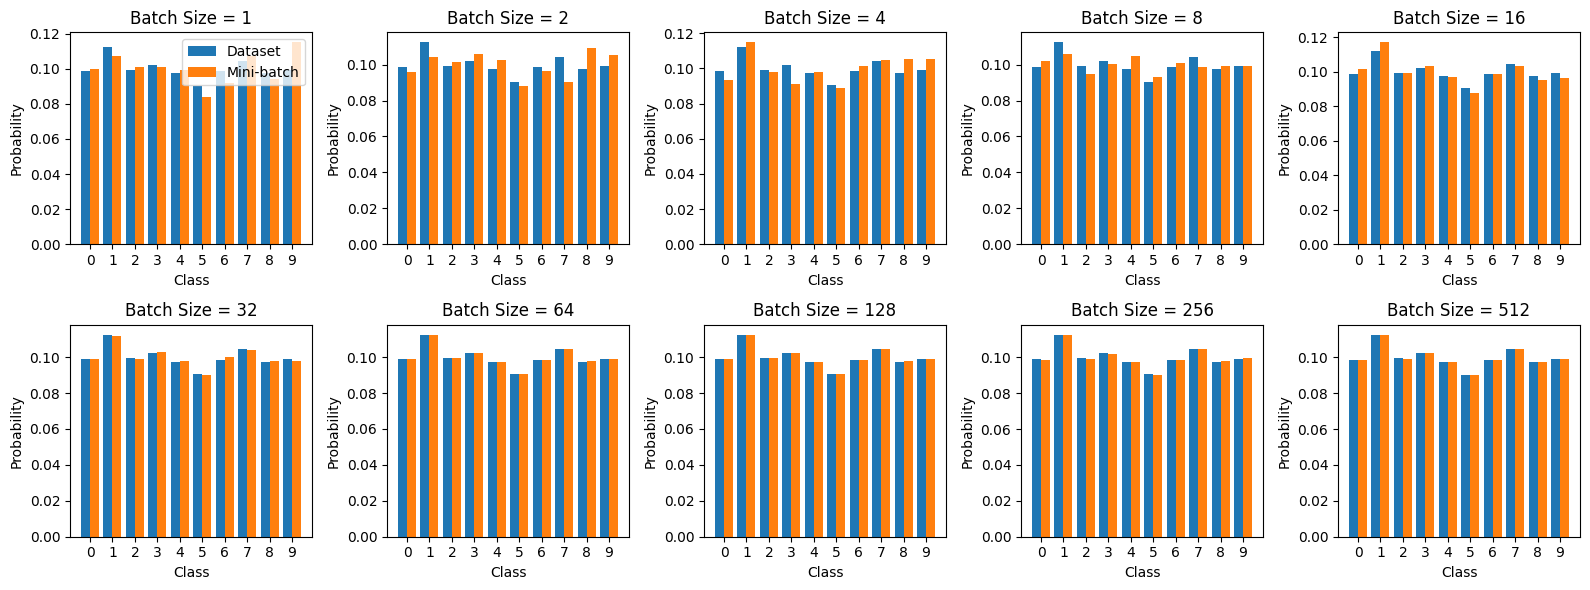

In [18]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
num_trials = 1000

results = {}

for batch_size in tqdm(batch_sizes):

    loader, _, _ = get_dataloaders(data_dir=data_dir,batch_size=batch_size,shuffle=True)

    avg_dist = np.zeros(10)
    count = 0

    for _, labels in loader:
        counts = Counter(labels.numpy())
        batch_dist = np.array([counts.get(i, 0) for i in range(10)], dtype=float)
        batch_dist /= batch_dist.sum()

        avg_dist += batch_dist
        count += 1
        if count == num_trials:
            break

    results[batch_size] = avg_dist / count

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.ravel()

for ax, batch_size in zip(axes, batch_sizes):
    ax.bar(np.arange(10) - 0.2, dataset_dist, width=0.4, label="Dataset")
    ax.bar(np.arange(10) + 0.2, results[batch_size], width=0.4, label="Mini-batch")

    ax.set_title(f"Batch Size = {batch_size}")
    ax.set_xticks(range(10))
    ax.set_xlabel("Class")
    ax.set_ylabel("Probability")

axes[0].legend()

plt.tight_layout()
plt.show()

### What does this figure tell?

- For **small batch sizes**, the class distribution varies noticeably due to the limited number of samples in each mini-batch.
- As the **batch size increases**, the average mini-batch distribution becomes increasingly similar to the distribution of the complete training dataset.
- For **batch sizes of 128 and above**, the mini-batch distribution closely matches the dataset distribution across all classes.
- This suggests that larger randomly sampled mini-batches are more representative of the underlying data distribution, providing empirical evidence in support of the ergodicity assumption.

### Step 3: Quantitative Verification using KL Divergence

While the histogram provides a qualitative comparison, a quantitative measure is required to evaluate how closely a mini-batch represents the full dataset.

The **Kullback-Leibler (KL) Divergence** is computed between the class distribution of each randomly sampled mini-batch and the complete training dataset. Lower KL Divergence indicates that the mini-batch distribution is closer to the dataset distribution.

In [20]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
num_batches = 1000
eps = 1e-10

kl_results = {}

for batch_size in tqdm(batch_sizes):

    loader, _, _ = get_dataloaders(
        data_dir=data_dir,
        batch_size=batch_size,
        shuffle=True,
    )

    kl_values = []

    for i, (_, labels) in enumerate(loader):

        counts = Counter(labels.numpy())
        batch_dist = np.array([counts.get(c, 0) for c in range(10)], dtype=float)
        batch_dist /= batch_dist.sum()

        kl = np.sum(batch_dist * np.log((batch_dist + eps) / (dataset_dist + eps)))
        kl_values.append(kl)

        if i + 1 == num_batches:
            break

    kl_results[batch_size] = {
        "mean": np.mean(kl_values),
        "std": np.std(kl_values),
    }

print(f"{'Batch Size':<12}{'Mean KL':<15}{'Std KL'}")
for bs in batch_sizes:
    print(f"{bs:<12}{kl_results[bs]['mean']:<15.6f}{kl_results[bs]['std']:.6f}")

100%|██████████████████████████████████████████| 10/10 [00:26<00:00,  2.61s/it]

Batch Size  Mean KL        Std KL
1           2.302799       0.049182
2           1.679921       0.213813
4           1.106604       0.214422
8           0.655894       0.191378
16          0.339866       0.140122
32          0.148693       0.071721
64          0.071892       0.034524
128         0.035599       0.016902
256         0.017664       0.007957
512         0.008753       0.003562


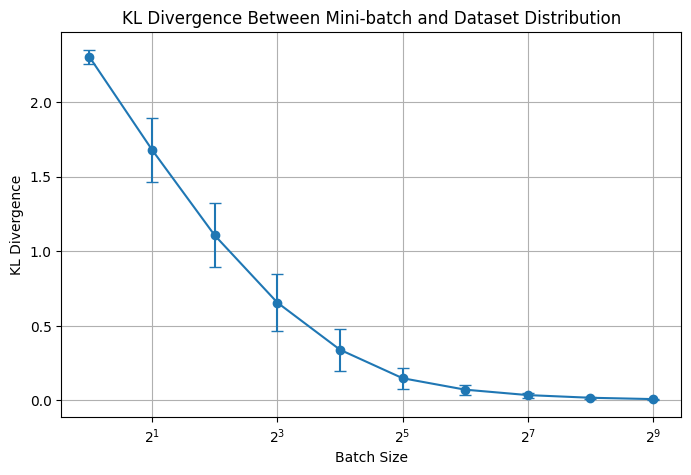

In [21]:
means = [kl_results[bs]["mean"] for bs in batch_sizes]
stds = [kl_results[bs]["std"] for bs in batch_sizes]

plt.figure(figsize=(8,5))
plt.errorbar(
    batch_sizes,
    means,
    yerr=stds,
    marker="o",
    capsize=4,
)

plt.xscale("log", base=2)
plt.xlabel("Batch Size")
plt.ylabel("KL Divergence")
plt.title("KL Divergence Between Mini-batch and Dataset Distribution")
plt.grid(True)
plt.show()